In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pyp
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
os.chdir("C:\\Users\khush\\OneDrive\\Documents\\csv\\")
os.getcwd()

'C:\\Users\\khush\\OneDrive\\Documents\\csv'

In [33]:
readFile = pd.read_csv("crop_yield.csv")
readFile

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667


In [34]:
readFile.info() #here we can see that we need to encode item and area.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [35]:
rows = readFile.shape[0]
cols = readFile.shape[1]

print(f"There are {rows} rows and {cols} colums.")

There are 19689 rows and 10 colums.


In [36]:
readFile.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [37]:
#removed one column as it was useless (storing serial numbers).

#fixing the name of columns
print("The old names of columns\n", readFile.columns)
print("\n")

readFile.columns  = readFile.columns.str.replace("_", " ").str.title().str.replace(" ", "")


print("The new names of columns\n", readFile.columns)

The old names of columns
 Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')


The new names of columns
 Index(['Crop', 'CropYear', 'Season', 'State', 'Area', 'Production',
       'AnnualRainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')


In [38]:
items = readFile["Crop"].unique() # checking how many types of crops are there
print(f"There are {len(items)} crops in dataset:\n\n", items)

There are 55 crops in dataset:

 ['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize' 'Mesta' 'Niger seed'
 'Onion' 'Other  Rabi pulses' 'Potato' 'Rapeseed &Mustard' 'Rice'
 'Sesamum' 'Small millets' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Tobacco'
 'Turmeric' 'Wheat' 'Bajra' 'Black pepper' 'Cardamom' 'Coriander' 'Garlic'
 'Ginger' 'Groundnut' 'Horse-gram' 'Jowar' 'Ragi' 'Cashewnut' 'Banana'
 'Soyabean' 'Barley' 'Khesari' 'Masoor' 'Moong(Green Gram)'
 'Other Kharif pulses' 'Safflower' 'Sannhamp' 'Sunflower' 'Urad'
 'Peas & beans (Pulses)' 'other oilseeds' 'Other Cereals' 'Cowpea(Lobia)'
 'Oilseeds total' 'Guar seed' 'Other Summer Pulses' 'Moth']


In [39]:
State = readFile["State"].unique() # checking how many types of countires are there
print(f"There are {len(State)} State in dataset:\n\n", State)

There are 30 State in dataset:

 ['Assam' 'Karnataka' 'Kerala' 'Meghalaya' 'West Bengal' 'Puducherry' 'Goa'
 'Andhra Pradesh' 'Tamil Nadu' 'Odisha' 'Bihar' 'Gujarat' 'Madhya Pradesh'
 'Maharashtra' 'Mizoram' 'Punjab' 'Uttar Pradesh' 'Haryana'
 'Himachal Pradesh' 'Tripura' 'Nagaland' 'Chhattisgarh' 'Uttarakhand'
 'Jharkhand' 'Delhi' 'Manipur' 'Jammu and Kashmir' 'Telangana'
 'Arunachal Pradesh' 'Sikkim']


In [40]:
print("Data is from year:", readFile["CropYear"].min(), "to", readFile["CropYear"].max())


Data is from year: 1997 to 2020


In [82]:
print(readFile["Season"].unique())

['Whole Year ' 'Kharif     ' 'Rabi       ' 'Autumn     ' 'Summer     '
 'Winter     ']


In [58]:
crop_lc = LabelEncoder()
cropYear_lc = LabelEncoder()
state_lc = LabelEncoder()
season_lc = LabelEncoder()
readFile["encodedCrop"] = crop_lc.fit_transform(readFile["Crop"])
readFile["encodedCropYear"] = cropYear_lc.fit_transform(readFile["CropYear"])
readFile["encodedState"] = state_lc.fit_transform(readFile["State"])
readFile["encodedSeason"] = season_lc.fit_transform(readFile["Season"])

readFile

,Crop,CropYear,Season,State,Area,Production,AnnualRainfall,Fertilizer,Pesticide,Yield,encodedCrop,encodedCropYear,encodedState,encodedSeason,Fertilizer_log,Pesticide_log
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087,0,0,2,4,15.764969,10.038164
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435,1,0,2,1,13.356082,7.629718
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333,8,0,2,1,11.235277,5.512461
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739,9,0,2,4,14.441803,8.715119
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909,11,0,2,1,12.016736,6.291736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000,44,1,19,1,12.887150,7.057037
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000,53,1,19,2,11.500863,5.673323
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000,24,0,10,1,17.202837,11.475999
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667,40,0,10,1,17.082900,11.356064


In [59]:
# Create one-hot encoded dataframe: Crop–Season mapping
crop_season_df = pd.get_dummies(readFile[['Crop', 'Season']], columns=['Season'])
crop_season_matrix = crop_season_df.groupby('Crop').max()

# Sort by total number of seasons per crop (optional)
crop_season_matrix['SeasonCount'] = crop_season_matrix.sum(axis=1)
crop_season_matrix = crop_season_matrix.sort_values('SeasonCount', ascending=False).drop('SeasonCount', axis=1)

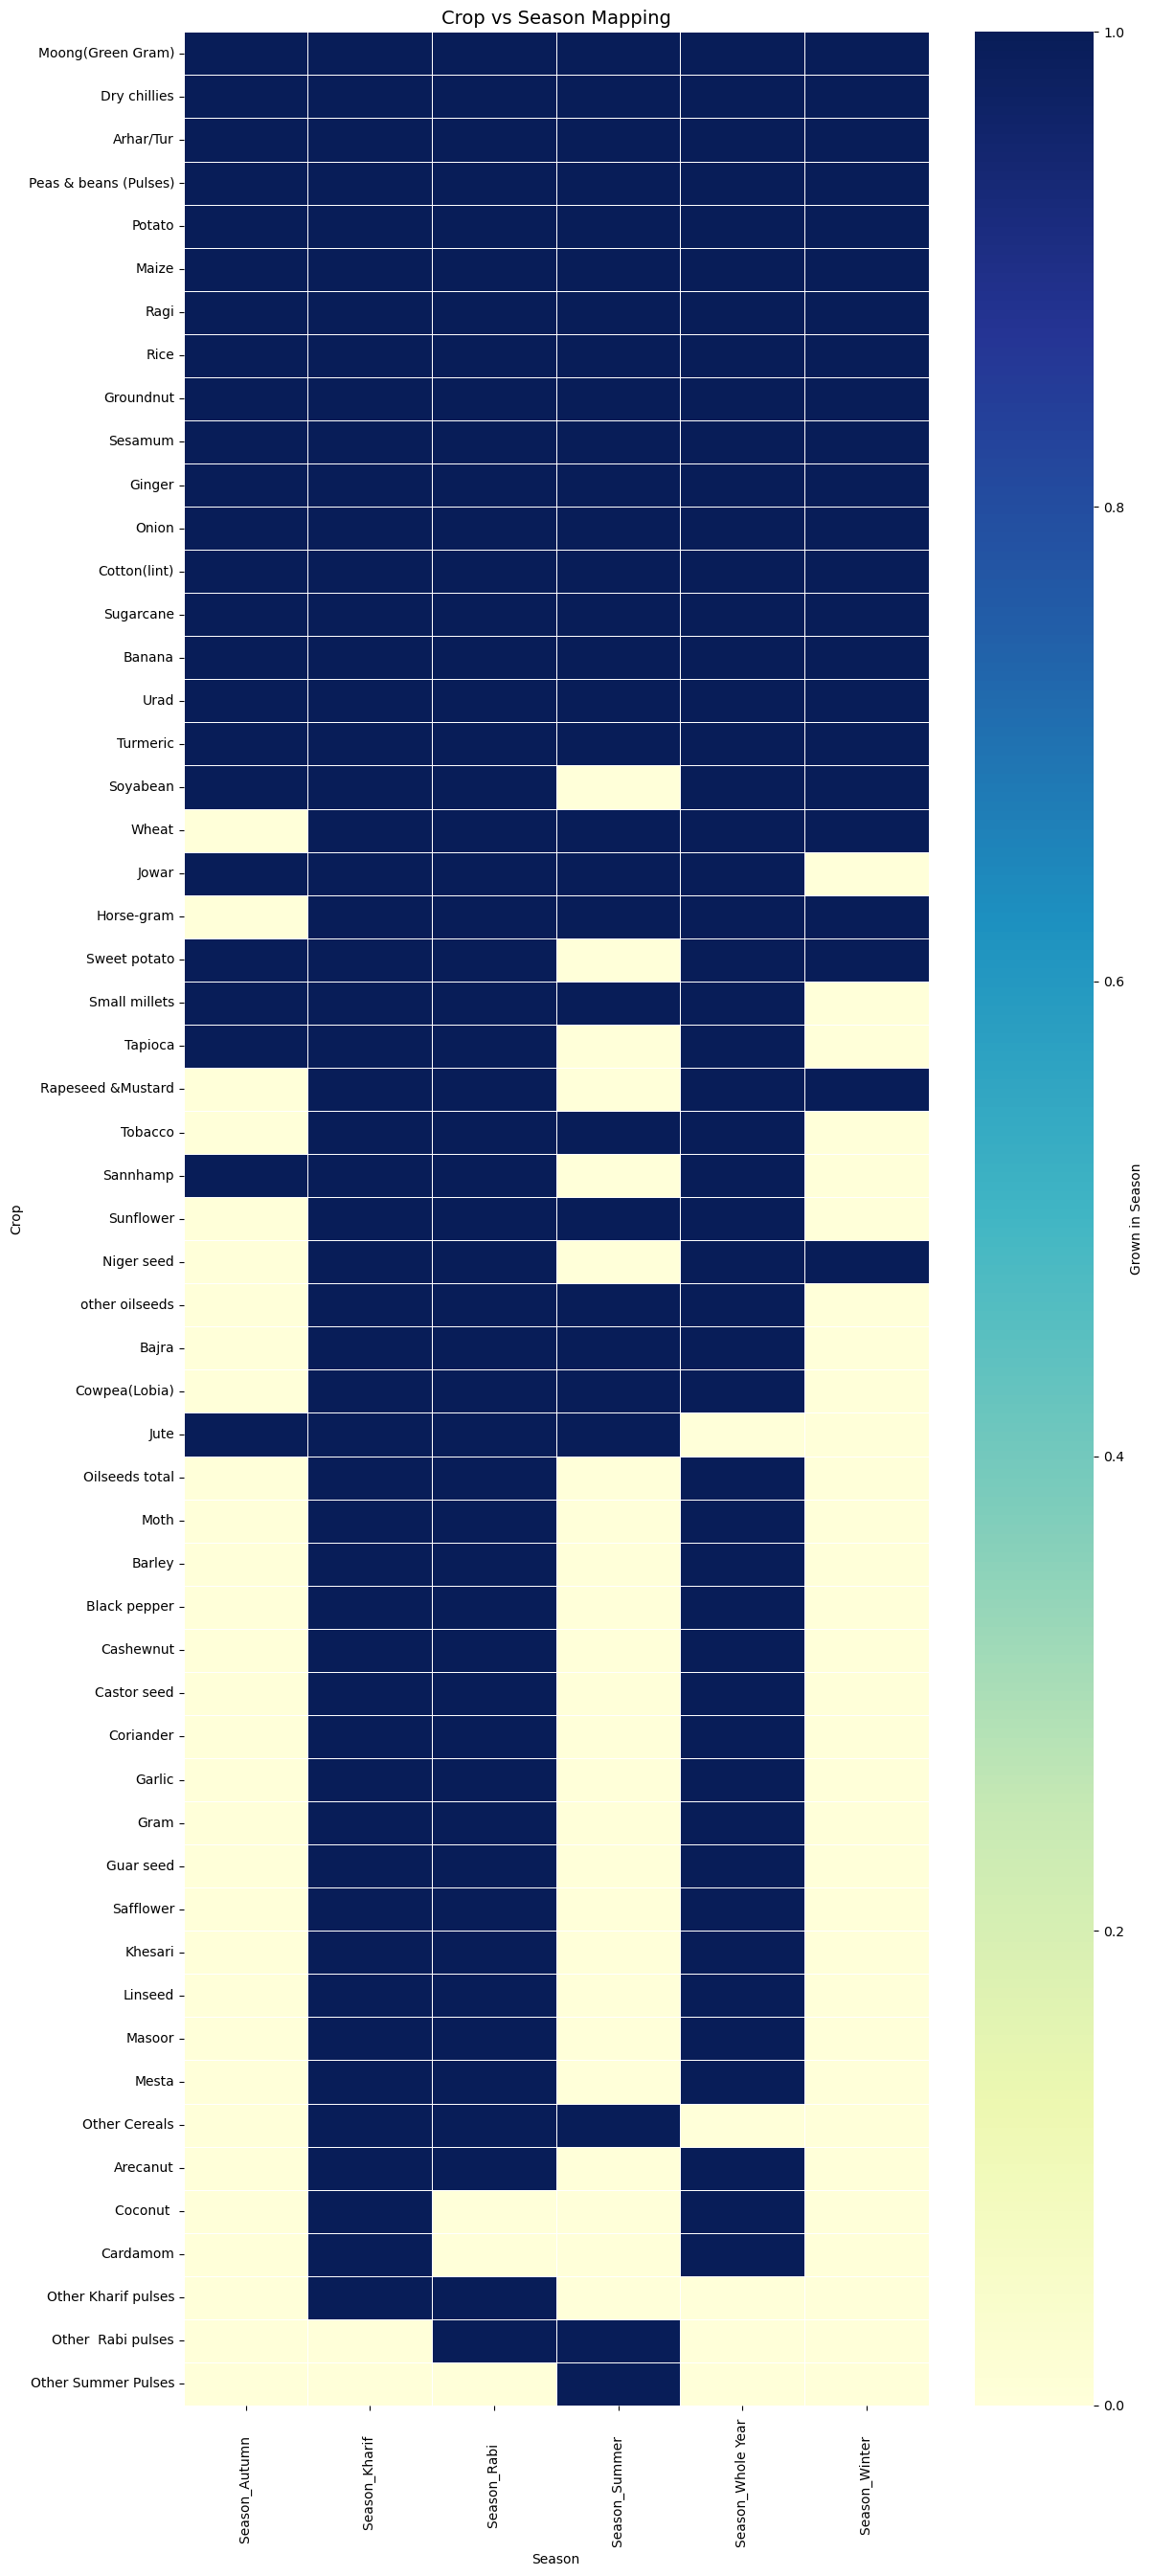

In [60]:
pyp.figure(figsize=(12, len(crop_season_matrix)//2))
sns.heatmap(crop_season_matrix, cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Grown in Season'})
pyp.title("Crop vs Season Mapping", fontsize=14)
pyp.xlabel("Season")
pyp.ylabel("Crop")
pyp.tight_layout()
pyp.show()


In [61]:
#the above heatmap shows in which season which crops grown blue represnt grown in this season while white reprsent no.

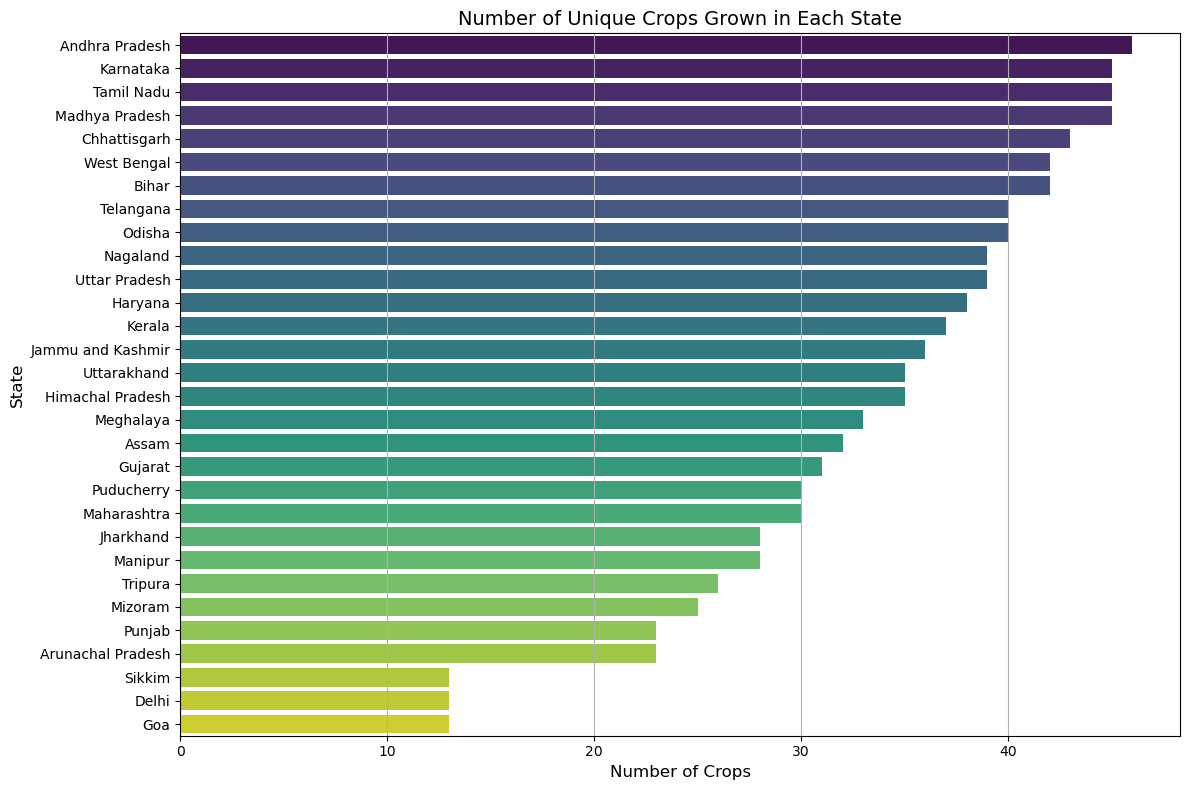

In [62]:
state_crop_count = readFile.groupby("State")["Crop"].nunique().sort_values(ascending=False)

# Plot
pyp.figure(figsize=(12, 8))
sns.barplot(x=state_crop_count.values, y=state_crop_count.index, palette="viridis")
pyp.title("Number of Unique Crops Grown in Each State", fontsize=14)
pyp.xlabel("Number of Crops", fontsize=12)
pyp.ylabel("State", fontsize=12)
pyp.grid(axis='x')
pyp.tight_layout()
pyp.show()


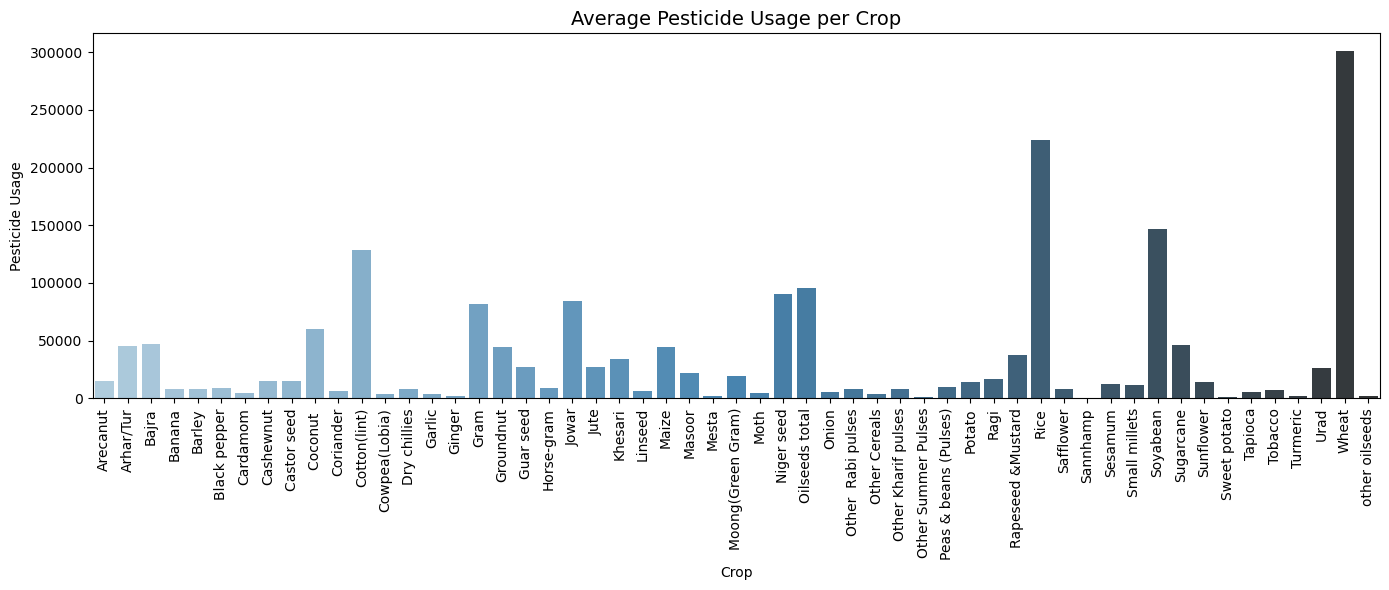

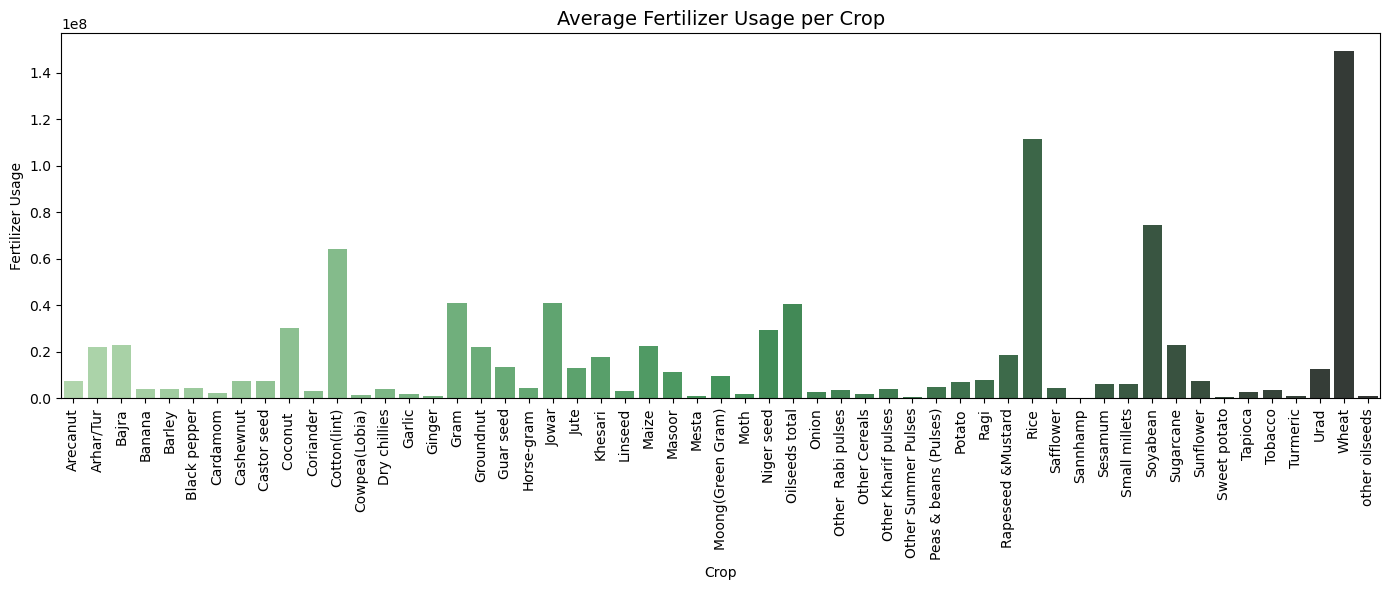

In [63]:
crop_usage = readFile.groupby("Crop")[["Pesticide", "Fertilizer"]].mean().reset_index()

# Pesticide Usage per Crop
pyp.figure(figsize=(14, 6))
sns.barplot(data=crop_usage, x="Crop", y="Pesticide", palette="Blues_d")
pyp.xticks(rotation=90)
pyp.title("Average Pesticide Usage per Crop", fontsize=14)
pyp.xlabel("Crop")
pyp.ylabel("Pesticide Usage")
pyp.tight_layout()
pyp.show()

#  Insecticide Usage per Crop
pyp.figure(figsize=(14, 6))
sns.barplot(data=crop_usage, x="Crop", y="Fertilizer", palette="Greens_d")
pyp.xticks(rotation=90)
pyp.title("Average Fertilizer Usage per Crop", fontsize=14)
pyp.xlabel("Crop")
pyp.ylabel("Fertilizer Usage")
pyp.tight_layout()
pyp.show()

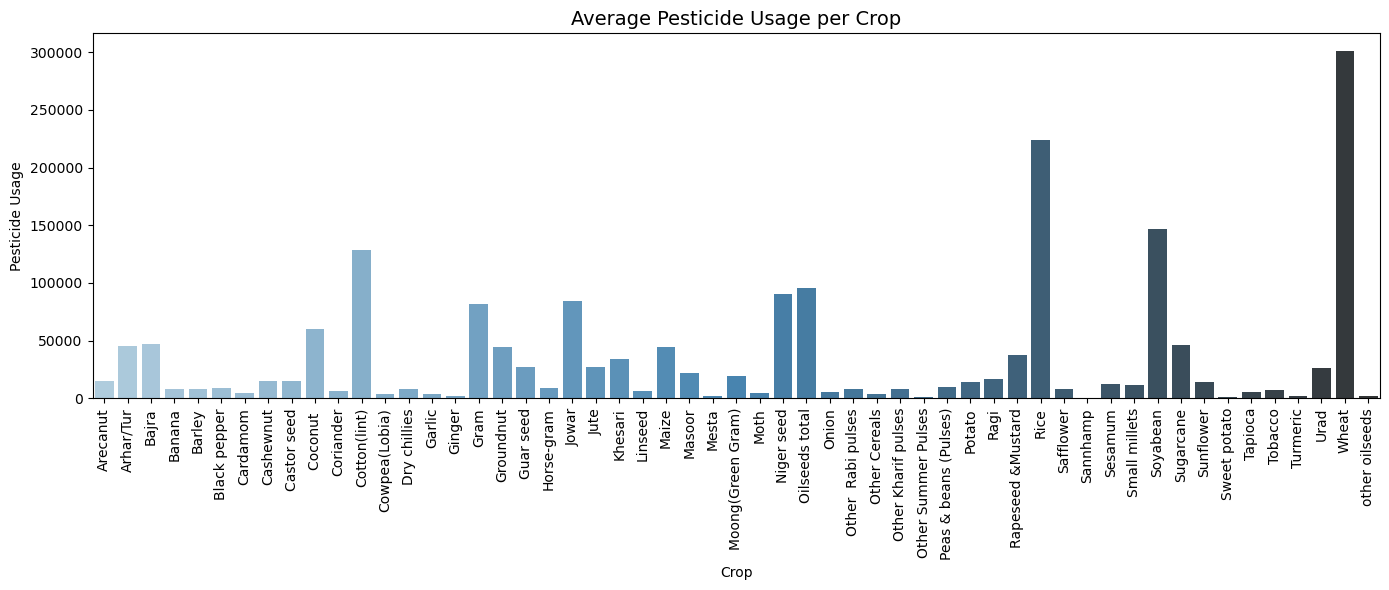

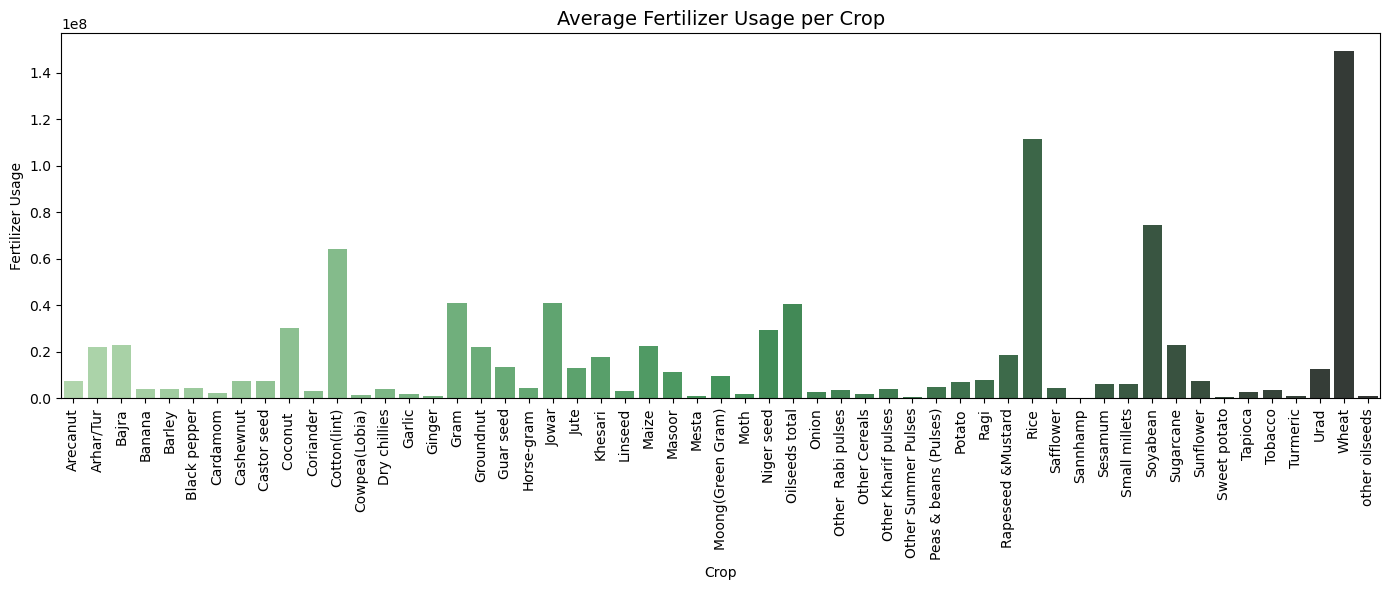

In [64]:
crop_usage = readFile.groupby("Crop")[["Pesticide", "Fertilizer"]].mean().reset_index()

# 🔹 Pesticide Usage per Crop
pyp.figure(figsize=(14, 6))
sns.barplot(data=crop_usage, x="Crop", y="Pesticide", palette="Blues_d")
pyp.xticks(rotation=90)
pyp.title("Average Pesticide Usage per Crop", fontsize=14)
pyp.xlabel("Crop")
pyp.ylabel("Pesticide Usage")
pyp.tight_layout()
pyp.show()

# 🔸 Insecticide Usage per Crop
pyp.figure(figsize=(14, 6))
sns.barplot(data=crop_usage, x="Crop", y="Fertilizer", palette="Greens_d")
pyp.xticks(rotation=90)
pyp.title("Average Fertilizer Usage per Crop", fontsize=14)
pyp.xlabel("Crop")
pyp.ylabel("Fertilizer Usage")
pyp.tight_layout()
pyp.show()

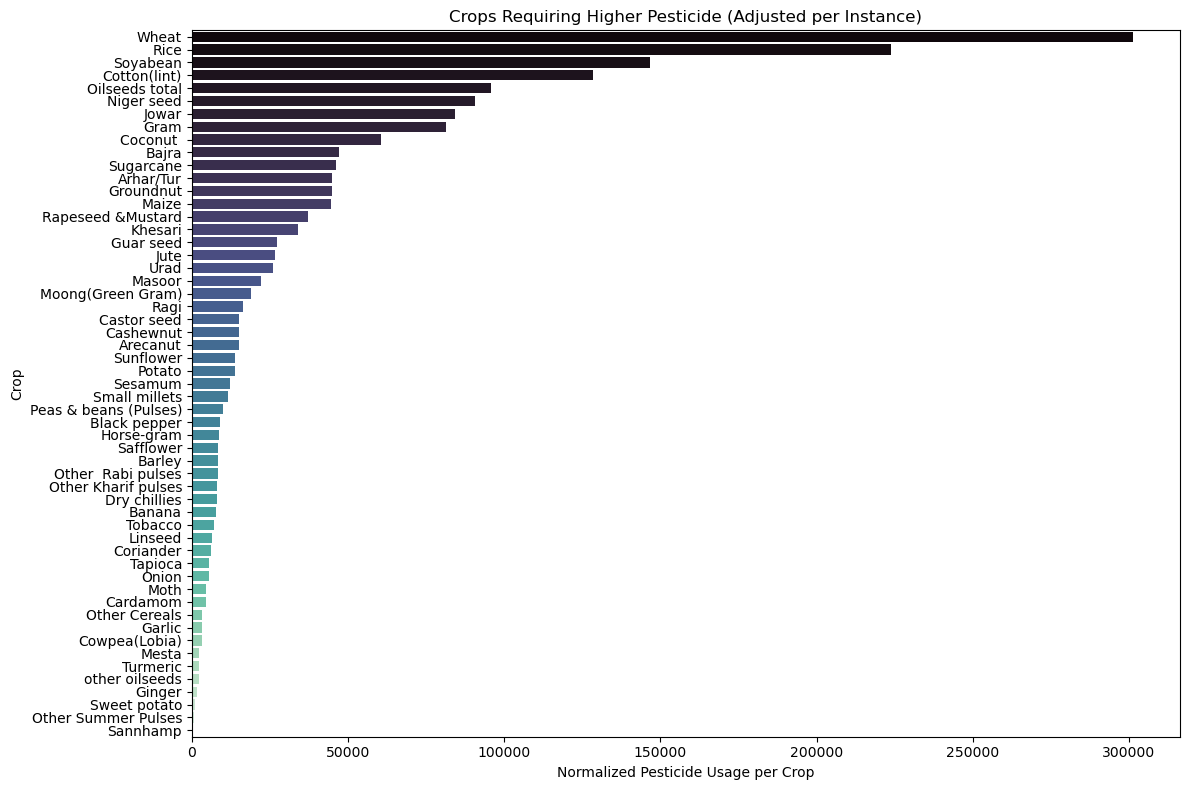

In [65]:
#wheat require more rainfall..
total_pesticide = readFile.groupby("Crop")["Pesticide"].sum()


crop_count = readFile["Crop"].value_counts()


pesticide_per_crop = total_pesticide / crop_count

pesticide_per_crop_sorted = pesticide_per_crop.sort_values(ascending=False)

pyp.figure(figsize=(12, 8))
sns.barplot(x=pesticide_per_crop_sorted.values[:55], y=pesticide_per_crop_sorted.index[:55], palette="mako")
pyp.xlabel("Normalized Pesticide Usage per Crop")
pyp.ylabel("Crop")
pyp.title("Crops Requiring Higher Pesticide (Adjusted per Instance)")
pyp.tight_layout()
pyp.show()


In [66]:
readFile["Crop"].value_counts()


Crop
Rice                     1197
Maize                     975
Moong(Green Gram)         740
Urad                      733
Groundnut                 725
Sesamum                   685
Potato                    628
Sugarcane                 605
Wheat                     545
Rapeseed &Mustard         528
Bajra                     524
Jowar                     513
Arhar/Tur                 508
Ragi                      498
Gram                      490
Small millets             485
Cotton(lint)              476
Onion                     454
Sunflower                 441
Dry chillies              419
Other Kharif pulses       382
Horse-gram                371
Peas & beans (Pulses)     369
Tobacco                   364
Other  Rabi pulses        355
Soyabean                  349
Turmeric                  337
Masoor                    324
Ginger                    323
Linseed                   308
Castor seed               300
Barley                    297
Sweet potato              273
Garli

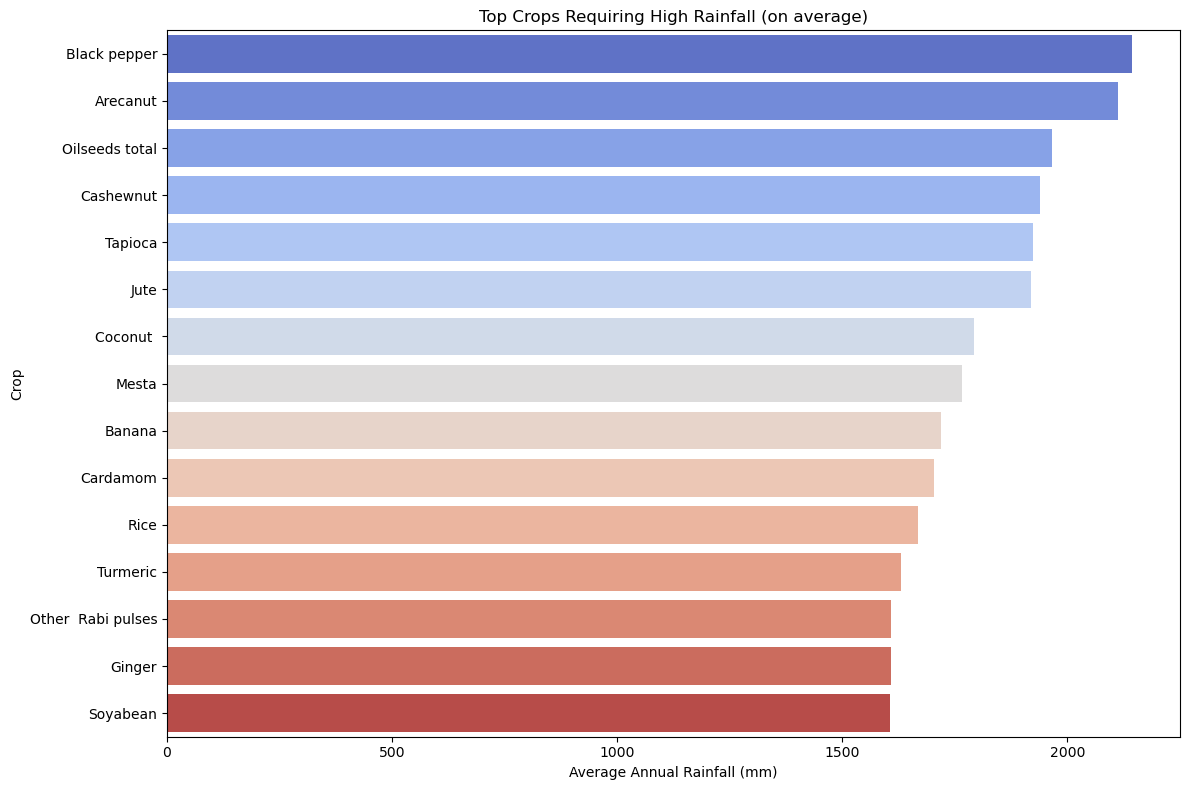

In [67]:
avg_rainfall_per_crop = readFile.groupby("Crop")["AnnualRainfall"].mean().sort_values(ascending=False)

# Plot
pyp.figure(figsize=(12, 8))
sns.barplot(x=avg_rainfall_per_crop.values[:15], y=avg_rainfall_per_crop.index[:15], palette="coolwarm")
pyp.xlabel("Average Annual Rainfall (mm)")
pyp.ylabel("Crop")
pyp.title("Top Crops Requiring High Rainfall (on average)")
pyp.tight_layout()
pyp.show()

In [75]:
# black pepper require more rainfall..
readFile["Fertilizer_log"] = np.log1p(readFile["Fertilizer"])
readFile["Pesticide_log"] = np.log1p(readFile["Pesticide"])
#now wanna check how these factor affect yield..
print(readFile[['AnnualRainfall', 'Fertilizer', 'Pesticide', 'Yield']].corr())

                AnnualRainfall  Fertilizer  Pesticide     Yield
AnnualRainfall        1.000000   -0.109734  -0.097657  0.020761
Fertilizer           -0.109734    1.000000   0.954991  0.002862
Pesticide            -0.097657    0.954991   1.000000  0.001782
Yield                 0.020761    0.002862   0.001782  1.000000


In [87]:
# yield is not affected by any of these..
print(readFile[['Crop', 'Area', 'AnnualRainfall', 'Fertilizer','Pesticide']].corr(numeric_only=True))


                    Area  AnnualRainfall  Fertilizer  Pesticide
Area            1.000000       -0.106054    0.973255   0.973479
AnnualRainfall -0.106054        1.000000   -0.109734  -0.097657
Fertilizer      0.973255       -0.109734    1.000000   0.954991
Pesticide       0.973479       -0.097657    0.954991   1.000000


In [77]:

X = readFile[['encodedCrop', 'encodedSeason', 'Area', 'AnnualRainfall']]
y = readFile[['Fertilizer', 'Pesticide']]
# here we can see more the more chemical and anuual rainfall required..
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


In [79]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [80]:

y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" R² Score:", r2*100,"%")
print(" RMSE:", rmse)


 R² Score: 95.47232850368978 %
 RMSE: 100872579785238.5


In [81]:
import joblib
joblib.dump(model, "crop_chemical_model.pkl")
joblib.dump(crop_lc, "crop_chemical_label_encoder_model.pkl")
joblib.dump(cropYear_lc, "crop_cropyear_label_encoder_model.pkl")
joblib.dump(state_lc, "crop_state_label_encoder_model.pkl")
joblib.dump(season_lc, "crop_season_label_encoder_model.pkl")


['crop_season_label_encoder_model.pkl']